In [1]:
from pathlib import Path

# Fixed project root for this research project
PROJECT_ROOT = Path(r"C:\Users\ZEUS\Documents\carbon_aware_marine_ai")

# Main project folders
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
EMISSIONS_DIR = OUTPUTS_DIR / "emissions"
CLOUD_SIM_DIR = OUTPUTS_DIR / "cloud_simulation"

FIGURES_DIR = PROJECT_ROOT / "figures"

# Creating folders safely
for folder in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    METRICS_DIR,
    EMISSIONS_DIR,
    CLOUD_SIM_DIR,
    FIGURES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Processed data folder:", PROCESSED_DATA_DIR)
print("Figures folder:", FIGURES_DIR)

Project root: C:\Users\ZEUS\Documents\carbon_aware_marine_ai
Raw data folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\raw
Processed data folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\processed
Figures folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures


In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Raw NetCDF file created in Notebook 02
raw_file_path = RAW_DATA_DIR / "oisst_south_florida_atlantic_coast_2021_2024.nc"

print("Raw file path:")
print(raw_file_path)
print("File exists:", raw_file_path.exists())

if not raw_file_path.exists():
    raise FileNotFoundError("Raw SST file was not found. Please check Notebook 02 output.")

# Opening the local NetCDF file
ds_local = xr.open_dataset(raw_file_path)

print("Dataset opened successfully.")
print(ds_local)

Raw file path:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\raw\oisst_south_florida_atlantic_coast_2021_2024.nc
File exists: True
Dataset opened successfully.
<xarray.Dataset> Size: 257kB
Dimensions:    (time: 1461, latitude: 7, longitude: 6)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2021-01-01T12:00:00 ... 2024-12-31T...
  * latitude   (latitude) float32 28B 25.38 25.62 25.88 26.12 26.38 26.62 26.88
  * longitude  (longitude) float32 24B 279.6 279.9 280.1 280.4 280.6 280.9
    depth      float32 4B ...
Data variables:
    sst        (time, latitude, longitude) float32 245kB ...


In [4]:
# Extracting the SST variable safely
if "sst" in ds_local.data_vars:
    sst_da = ds_local["sst"]
else:
    first_variable = list(ds_local.data_vars)[0]
    print("SST variable not found by name. Using first variable:", first_variable)
    sst_da = ds_local[first_variable]

print("SST DataArray:")
print(sst_da)

print("\nDimensions:", sst_da.dims)
print("Shape:", sst_da.shape)
print("Units:", sst_da.attrs.get("units", "Not listed"))

SST DataArray:
<xarray.DataArray 'sst' (time: 1461, latitude: 7, longitude: 6)> Size: 245kB
[61362 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 12kB 2021-01-01T12:00:00 ... 2024-12-31T...
  * latitude   (latitude) float32 28B 25.38 25.62 25.88 26.12 26.38 26.62 26.88
  * longitude  (longitude) float32 24B 279.6 279.9 280.1 280.4 280.6 280.9
    depth      float32 4B ...
Attributes:
    _ChunkSizes:  [   1    1  720 1440]
    long_name:    Daily sea surface temperature
    units:        Celsius
    valid_max:    4500.0
    valid_min:    -300.0

Dimensions: ('time', 'latitude', 'longitude')
Shape: (1461, 7, 6)
Units: Celsius


In [5]:
# Basic quality summary
total_values = sst_da.size
missing_values = int(sst_da.isnull().sum().values)
missing_percent = (missing_values / total_values) * 100

sst_min = float(sst_da.min(skipna=True).values)
sst_max = float(sst_da.max(skipna=True).values)

print("Total values:", total_values)
print("Missing values:", missing_values)
print("Missing percentage:", round(missing_percent, 2), "%")
print("SST minimum:", round(sst_min, 3), "°C")
print("SST maximum:", round(sst_max, 3), "°C")

Total values: 61362
Missing values: 14610
Missing percentage: 23.81 %
SST minimum: 22.19 °C
SST maximum: 32.05 °C


In [6]:
# Calculating how often each grid cell has valid SST data
valid_fraction = sst_da.notnull().mean(dim="time")

# Keeping grid cells that have SST data for at least 90% of the days
valid_ocean_mask = valid_fraction >= 0.90

valid_ocean_cells = int(valid_ocean_mask.sum().values)
total_grid_cells = sst_da.sizes["latitude"] * sst_da.sizes["longitude"]

print("Total grid cells:", total_grid_cells)
print("Valid ocean grid cells:", valid_ocean_cells)
print("Removed land/coastal invalid cells:", total_grid_cells - valid_ocean_cells)
print("Valid ocean cell percentage:", round((valid_ocean_cells / total_grid_cells) * 100, 2), "%")

Total grid cells: 42
Valid ocean grid cells: 32
Removed land/coastal invalid cells: 10
Valid ocean cell percentage: 76.19 %


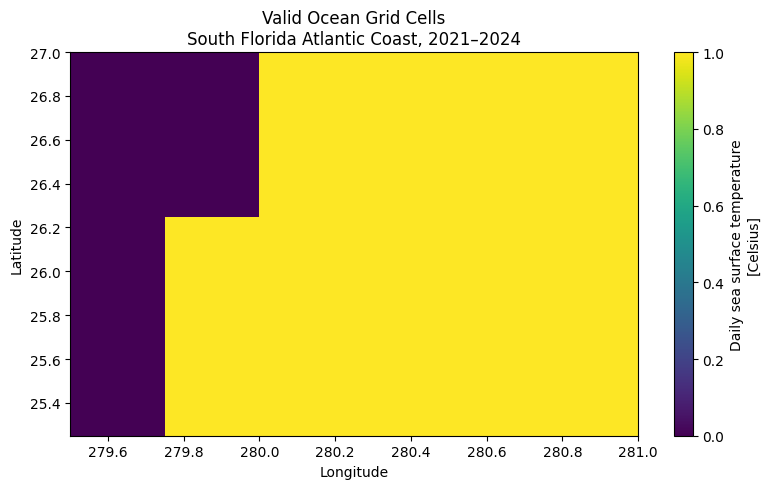

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\valid_ocean_grid_cells_south_florida_atlantic.png
File exists: True


In [7]:
plt.figure(figsize=(8, 5))

valid_ocean_mask.plot()

plt.title("Valid Ocean Grid Cells\nSouth Florida Atlantic Coast, 2021–2024")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

figure_path = FIGURES_DIR / "valid_ocean_grid_cells_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

In [8]:
# Applying the valid ocean mask
sst_ocean = sst_da.where(valid_ocean_mask)

print("Ocean-filtered SST data:")
print(sst_ocean)

# Checking missing values after masking
remaining_missing = int(sst_ocean.isnull().sum().values)
remaining_missing_percent = (remaining_missing / sst_ocean.size) * 100

print("\nRemaining missing values:", remaining_missing)
print("Remaining missing percentage:", round(remaining_missing_percent, 2), "%")

Ocean-filtered SST data:
<xarray.DataArray 'sst' (time: 1461, latitude: 7, longitude: 6)> Size: 245kB
array([[[      nan, 24.97    , 25.769999, 26.18    , 25.46    ,
         23.689999],
        [      nan, 24.66    , 25.55    , 26.      , 25.34    ,
         23.789999],
        [      nan, 24.539999, 25.41    , 26.      , 25.64    ,
         24.49    ],
        ...,
        [      nan,       nan, 25.33    , 26.039999, 26.359999,
         25.939999],
        [      nan,       nan, 25.35    , 25.98    , 26.039999,
         25.189999],
        [      nan,       nan, 25.199999, 25.8     , 25.66    ,
         24.449999]],

       [[      nan, 24.869999, 25.58    , 26.09    , 25.55    ,
         23.83    ],
        [      nan, 24.58    , 25.439999, 25.89    , 25.3     ,
         23.75    ],
        [      nan, 24.43    , 25.33    , 25.869999, 25.47    ,
         24.34    ],
...
        [      nan,       nan, 25.99    , 26.519999, 26.609999,
         26.      ],
        [      nan,       nan

In [9]:
# Converting the gridded SST data into a tabular DataFrame
sst_df = sst_ocean.to_dataframe(name="sst").reset_index()

# Removing rows where SST is missing
sst_df = sst_df.dropna(subset=["sst"]).copy()

# Converting NOAA 0–360 longitude into normal -180 to 180 longitude
sst_df["longitude_0_360"] = sst_df["longitude"]
sst_df["longitude_deg"] = sst_df["longitude"] - 360

# Dropping the original longitude column to avoid confusion
sst_df = sst_df.drop(columns=["longitude"])

# Reordering columns
sst_df = sst_df[
    [
        "time",
        "latitude",
        "longitude_0_360",
        "longitude_deg",
        "sst"
    ]
]

print("Clean SST DataFrame created.")
print("Shape:", sst_df.shape)
sst_df.head()

Clean SST DataFrame created.
Shape: (46752, 5)


,time,latitude,longitude_0_360,longitude_deg,sst
1,2021-01-01 12:00:00,25.375,279.875,-80.125,24.969999
2,2021-01-01 12:00:00,25.375,280.125,-79.875,25.769999
3,2021-01-01 12:00:00,25.375,280.375,-79.625,26.180000
4,2021-01-01 12:00:00,25.375,280.625,-79.375,25.459999
5,2021-01-01 12:00:00,25.375,280.875,-79.125,23.689999


In [10]:
# Creating a stable grid cell ID for each latitude-longitude point
sst_df["grid_id"] = (
    sst_df["latitude"].round(3).astype(str)
    + "_"
    + sst_df["longitude_deg"].round(3).astype(str)
)

unique_grid_cells = sst_df["grid_id"].nunique()

print("Unique valid ocean grid cells:", unique_grid_cells)
sst_df.head()

Unique valid ocean grid cells: 32


,time,latitude,longitude_0_360,longitude_deg,sst,grid_id
1,2021-01-01 12:00:00,25.375,279.875,-80.125,24.969999,25.375_-80.125
2,2021-01-01 12:00:00,25.375,280.125,-79.875,25.769999,25.375_-79.875
3,2021-01-01 12:00:00,25.375,280.375,-79.625,26.180000,25.375_-79.625
4,2021-01-01 12:00:00,25.375,280.625,-79.375,25.459999,25.375_-79.375
5,2021-01-01 12:00:00,25.375,280.875,-79.125,23.689999,25.375_-79.125


In [11]:
# Creating time-based features
sst_df["time"] = pd.to_datetime(sst_df["time"])

sst_df["year"] = sst_df["time"].dt.year
sst_df["month"] = sst_df["time"].dt.month
sst_df["day_of_year"] = sst_df["time"].dt.dayofyear

# Cyclical seasonal encoding
sst_df["month_sin"] = np.sin(2 * np.pi * sst_df["month"] / 12)
sst_df["month_cos"] = np.cos(2 * np.pi * sst_df["month"] / 12)

sst_df["day_sin"] = np.sin(2 * np.pi * sst_df["day_of_year"] / 365.25)
sst_df["day_cos"] = np.cos(2 * np.pi * sst_df["day_of_year"] / 365.25)

print("Time features added.")
sst_df.head()

Time features added.


,time,latitude,longitude_0_360,longitude_deg,sst,grid_id,year,month,day_of_year,month_sin,month_cos,day_sin,day_cos
1,2021-01-01 12:00:00,25.375,279.875,-80.125,24.969999,25.375_-80.125,2021,1,1,0.5,0.866025,0.017202,0.999852
2,2021-01-01 12:00:00,25.375,280.125,-79.875,25.769999,25.375_-79.875,2021,1,1,0.5,0.866025,0.017202,0.999852
3,2021-01-01 12:00:00,25.375,280.375,-79.625,26.180000,25.375_-79.625,2021,1,1,0.5,0.866025,0.017202,0.999852
4,2021-01-01 12:00:00,25.375,280.625,-79.375,25.459999,25.375_-79.375,2021,1,1,0.5,0.866025,0.017202,0.999852
5,2021-01-01 12:00:00,25.375,280.875,-79.125,23.689999,25.375_-79.125,2021,1,1,0.5,0.866025,0.017202,0.999852


In [12]:
# Sorting by grid cell and time before creating lag features
sst_df = sst_df.sort_values(["grid_id", "time"]).reset_index(drop=True)

# Grouping by grid cell
grid_group = sst_df.groupby("grid_id")["sst"]

# Lag features from previous days
sst_df["sst_lag_1"] = grid_group.shift(1)
sst_df["sst_lag_2"] = grid_group.shift(2)
sst_df["sst_lag_3"] = grid_group.shift(3)
sst_df["sst_lag_7"] = grid_group.shift(7)
sst_df["sst_lag_14"] = grid_group.shift(14)

# Rolling features using previous values
sst_df["sst_rolling_mean_7"] = (
    grid_group.shift(1)
    .groupby(sst_df["grid_id"])
    .rolling(window=7, min_periods=3)
    .mean()
    .reset_index(level=0, drop=True)
)

sst_df["sst_rolling_std_7"] = (
    grid_group.shift(1)
    .groupby(sst_df["grid_id"])
    .rolling(window=7, min_periods=3)
    .std()
    .reset_index(level=0, drop=True)
)

print("Lag and rolling features created.")
sst_df.head(15)

Lag and rolling features created.


,time,latitude,longitude_0_360,longitude_deg,sst,grid_id,year,month,day_of_year,month_sin,month_cos,day_sin,day_cos,sst_lag_1,sst_lag_2,sst_lag_3,sst_lag_7,sst_lag_14,sst_rolling_mean_7,sst_rolling_std_7
0,2021-01-01 12:00:00,25.375,280.875,-79.125,23.689999,25.375_-79.125,2021,1,1,0.5,0.866025,0.017202,0.999852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02 12:00:00,25.375,280.875,-79.125,23.830000,25.375_-79.125,2021,1,2,0.5,0.866025,0.034398,0.999408,23.689999,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03 12:00:00,25.375,280.875,-79.125,23.980000,25.375_-79.125,2021,1,3,0.5,0.866025,0.051584,0.998669,23.830000,23.689999,NaN,NaN,NaN,NaN,NaN
3,2021-01-04 12:00:00,25.375,280.875,-79.125,24.019999,25.375_-79.125,2021,1,4,0.5,0.866025,0.068755,0.997634,23.980000,23.830000,23.689999,NaN,NaN,23.833333,0.145029
4,2021-01-05 12:00:00,25.375,280.875,-79.125,23.980000,25.375_-79.125,2021,1,5,0.5,0.866025,0.085906,0.996303,24.019999,23.980000,23.830000,NaN,NaN,23.879999,0.150776
5,2021-01-06 12:00:00,25.375,280.875,-79.125,23.799999,25.375_-79.125,2021,1,6,0.5,0.866025,0.103031,0.994678,23.980000,24.019999,23.980000,NaN,NaN,23.899999,0.138022
6,2021-01-07 12:00:00,25.375,280.875,-79.125,23.930000,25.375_-79.125,2021,1,7,0.5,0.866025,0.120126,0.992759,23.799999,23.980000,24.019999,NaN,NaN,23.883333,0.130026
7,2021-01-08 12:00:00,25.375,280.875,-79.125,23.889999,25.375_-79.125,2021,1,8,0.5,0.866025,0.137185,0.990545,23.930000,23.799999,23.980000,23.689999,NaN,23.889999,0.120000
8,2021-01-09 12:00:00,25.375,280.875,-79.125,23.820000,25.375_-79.125,2021,1,9,0.5,0.866025,0.154204,0.988039,23.889999,23.930000,23.799999,23.830000,NaN,23.918571,0.082346
9,2021-01-10 12:00:00,25.375,280.875,-79.125,23.920000,25.375_-79.125,2021,1,10,0.5,0.866025,0.171177,0.985240,23.820000,23.889999,23.930000,23.980000,NaN,23.917142,0.084205


In [13]:
# Creating the prediction target
# Target: next-day SST for the same ocean grid cell
sst_df["target_sst_next_day"] = sst_df.groupby("grid_id")["sst"].shift(-1)

print("Next-day SST target created.")
sst_df[["time", "grid_id", "sst", "target_sst_next_day"]].head(10)

Next-day SST target created.


,time,grid_id,sst,target_sst_next_day
0,2021-01-01 12:00:00,25.375_-79.125,23.689999,23.830000
1,2021-01-02 12:00:00,25.375_-79.125,23.830000,23.980000
2,2021-01-03 12:00:00,25.375_-79.125,23.980000,24.019999
3,2021-01-04 12:00:00,25.375_-79.125,24.019999,23.980000
4,2021-01-05 12:00:00,25.375_-79.125,23.980000,23.799999
5,2021-01-06 12:00:00,25.375_-79.125,23.799999,23.930000
6,2021-01-07 12:00:00,25.375_-79.125,23.930000,23.889999
7,2021-01-08 12:00:00,25.375_-79.125,23.889999,23.820000
8,2021-01-09 12:00:00,25.375_-79.125,23.820000,23.920000
9,2021-01-10 12:00:00,25.375_-79.125,23.920000,23.809999


In [14]:
# Selecting final model columns
feature_columns = [
    "latitude",
    "longitude_deg",
    "year",
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "sst",
    "sst_lag_1",
    "sst_lag_2",
    "sst_lag_3",
    "sst_lag_7",
    "sst_lag_14",
    "sst_rolling_mean_7",
    "sst_rolling_std_7"
]

target_column = "target_sst_next_day"

metadata_columns = [
    "time",
    "grid_id",
    "longitude_0_360"
]

final_columns = metadata_columns + feature_columns + [target_column]

ml_df = sst_df[final_columns].dropna().copy()

print("ML-ready DataFrame created.")
print("Original clean rows:", len(sst_df))
print("Final ML rows:", len(ml_df))
print("Rows removed due to lag/target NaNs:", len(sst_df) - len(ml_df))
print("Unique grid cells:", ml_df["grid_id"].nunique())

ml_df.head()

ML-ready DataFrame created.
Original clean rows: 46752
Final ML rows: 46272
Rows removed due to lag/target NaNs: 480
Unique grid cells: 32


,time,grid_id,longitude_0_360,latitude,longitude_deg,year,month,day_of_year,month_sin,month_cos,...,day_cos,sst,sst_lag_1,sst_lag_2,sst_lag_3,sst_lag_7,sst_lag_14,sst_rolling_mean_7,sst_rolling_std_7,target_sst_next_day
14,2021-01-15 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,15,0.5,0.866025,...,0.966893,23.459999,23.180000,23.369999,23.680000,23.889999,23.689999,23.667143,0.283767,24.029999
15,2021-01-16 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,16,0.5,0.866025,...,0.962360,24.029999,23.459999,23.180000,23.369999,23.820000,23.830000,23.605714,0.273853,24.260000
16,2021-01-17 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,17,0.5,0.866025,...,0.957543,24.260000,24.029999,23.459999,23.180000,23.920000,23.980000,23.635714,0.310315,23.969999
17,2021-01-18 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,18,0.5,0.866025,...,0.952442,23.969999,24.260000,24.029999,23.459999,23.809999,24.019999,23.684285,0.380826,24.090000
18,2021-01-19 12:00:00,25.375_-79.125,280.875,25.375,-79.125,2021,1,19,0.5,0.866025,...,0.947060,24.090000,23.969999,24.260000,24.029999,23.680000,23.980000,23.707142,0.394196,23.430000


In [15]:
print("Final ML dataset summary")
print("------------------------")
print("Rows:", len(ml_df))
print("Columns:", len(ml_df.columns))
print("Start date:", ml_df["time"].min())
print("End date:", ml_df["time"].max())
print("Unique grid cells:", ml_df["grid_id"].nunique())
print("SST range:", round(ml_df["sst"].min(), 3), "to", round(ml_df["sst"].max(), 3))
print("Target range:", round(ml_df["target_sst_next_day"].min(), 3), "to", round(ml_df["target_sst_next_day"].max(), 3))

ml_df.describe()

Final ML dataset summary
------------------------
Rows: 46272
Columns: 21
Start date: 2021-01-15 12:00:00
End date: 2024-12-30 12:00:00
Unique grid cells: 32
SST range: 22.19 to 32.05
Target range: 22.19 to 32.05


,time,longitude_0_360,latitude,longitude_deg,year,month,day_of_year,month_sin,month_cos,day_sin,day_cos,sst,sst_lag_1,sst_lag_2,sst_lag_3,sst_lag_7,sst_lag_14,sst_rolling_mean_7,sst_rolling_std_7,target_sst_next_day
count,46272,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,4.627200e+04,4.627200e+04,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000,46272.000000
mean,2023-01-08 00:00:00,280.421875,26.078125,-79.578125,2022.514523,6.572614,184.699170,-9.675229e-03,-1.112618e-02,-0.001247,-0.010270,27.749422,27.747995,27.747017,27.746481,27.744452,27.740778,27.746032,0.190018,27.750614
min,2021-01-15 12:00:00,279.875000,25.375000,-80.125000,2021.000000,1.000000,1.000000,-1.000000e+00,-1.000000e+00,-0.999999,-0.999979,22.189999,22.189999,22.189999,22.189999,22.189999,22.189999,22.971428,0.008998,22.189999
25%,2022-01-11 12:00:00,280.125000,25.625000,-79.875000,2022.000000,4.000000,94.000000,-8.660254e-01,-8.660254e-01,-0.714292,-0.710520,26.170000,26.170000,26.160000,26.160000,26.160000,26.150000,26.148571,0.105017,26.170000
50%,2023-01-08 00:00:00,280.375000,26.125000,-79.625000,2023.000000,7.000000,185.000000,-2.449294e-16,-1.836970e-16,-0.021501,-0.016127,27.719999,27.719999,27.719999,27.719999,27.719999,27.719999,27.714285,0.162011,27.719999
75%,2024-01-04 12:00:00,280.625000,26.437500,-79.375000,2024.000000,10.000000,275.000000,5.000000e-01,5.000000e-01,0.711276,0.690574,29.469999,29.469999,29.469999,29.469999,29.469999,29.469999,29.472857,0.243772,29.469999
max,2024-12-30 12:00:00,280.875000,26.875000,-79.125000,2024.000000,12.000000,365.000000,1.000000e+00,1.000000e+00,0.999986,0.999991,32.049999,32.049999,32.049999,32.049999,32.049999,32.049999,31.742856,1.675664,32.049999
std,NaN,0.333296,0.493864,0.333296,1.113613,3.420328,104.443646,7.076593e-01,7.064153e-01,0.710627,0.703508,1.838692,1.840888,1.842257,1.842909,1.845219,1.849184,1.831522,0.121400,1.836955


In [16]:
ml_output_path = PROCESSED_DATA_DIR / "sst_ml_features_south_florida_atlantic_2021_2024.csv"

ml_df.to_csv(ml_output_path, index=False)

print("ML-ready dataset saved to:")
print(ml_output_path)
print("File exists:", ml_output_path.exists())
print("Shape:", ml_df.shape)

ML-ready dataset saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\processed\sst_ml_features_south_florida_atlantic_2021_2024.csv
File exists: True
Shape: (46272, 21)


In [17]:
# Creating cleaned regional mean SST from valid ocean grid cells only
clean_regional_mean = (
    sst_df
    .groupby("time", as_index=False)["sst"]
    .mean()
    .rename(columns={"sst": "clean_regional_mean_sst"})
)

clean_regional_mean_output_path = PROCESSED_DATA_DIR / "clean_regional_mean_sst_south_florida_atlantic_2021_2024.csv"

clean_regional_mean.to_csv(clean_regional_mean_output_path, index=False)

print("Clean regional mean SST saved to:")
print(clean_regional_mean_output_path)
print("File exists:", clean_regional_mean_output_path.exists())

clean_regional_mean.head()

Clean regional mean SST saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\processed\clean_regional_mean_sst_south_florida_atlantic_2021_2024.csv
File exists: True


,time,clean_regional_mean_sst
0,2021-01-01 12:00:00,25.381561
1,2021-01-02 12:00:00,25.212500
2,2021-01-03 12:00:00,25.319374
3,2021-01-04 12:00:00,25.296562
4,2021-01-05 12:00:00,25.340937


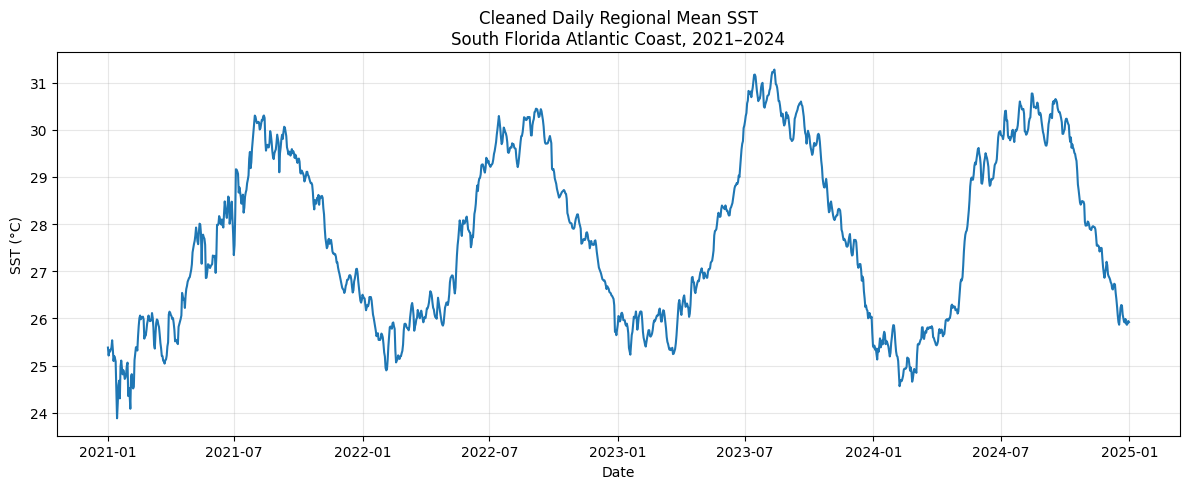

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\cleaned_regional_mean_sst_south_florida_atlantic_2021_2024.png
File exists: True


In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    clean_regional_mean["time"],
    clean_regional_mean["clean_regional_mean_sst"]
)

plt.title("Cleaned Daily Regional Mean SST\nSouth Florida Atlantic Coast, 2021–2024")
plt.xlabel("Date")
plt.ylabel("SST (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "cleaned_regional_mean_sst_south_florida_atlantic_2021_2024.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

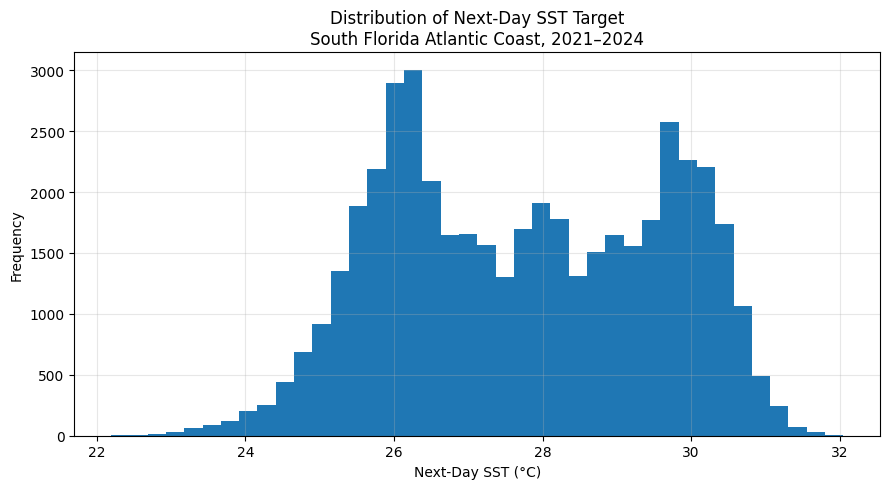

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\target_sst_distribution_south_florida_atlantic.png
File exists: True


In [19]:
plt.figure(figsize=(9, 5))

plt.hist(ml_df["target_sst_next_day"], bins=40)

plt.title("Distribution of Next-Day SST Target\nSouth Florida Atlantic Coast, 2021–2024")
plt.xlabel("Next-Day SST (°C)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "target_sst_distribution_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

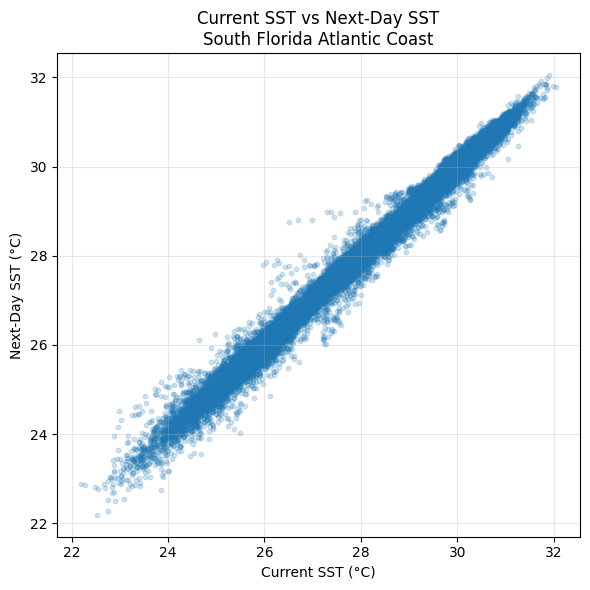

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\current_sst_vs_next_day_sst_south_florida_atlantic.png
File exists: True


In [20]:
plt.figure(figsize=(6, 6))

plt.scatter(
    ml_df["sst"],
    ml_df["target_sst_next_day"],
    alpha=0.2,
    s=10
)

plt.title("Current SST vs Next-Day SST\nSouth Florida Atlantic Coast")
plt.xlabel("Current SST (°C)")
plt.ylabel("Next-Day SST (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "current_sst_vs_next_day_sst_south_florida_atlantic.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

In [21]:
preprocessing_summary = {
    "raw_file": str(raw_file_path),
    "processed_ml_file": str(ml_output_path),
    "clean_regional_mean_file": str(clean_regional_mean_output_path),
    "original_total_values": total_values,
    "original_missing_values": missing_values,
    "original_missing_percent": round(missing_percent, 2),
    "total_grid_cells": total_grid_cells,
    "valid_ocean_grid_cells": valid_ocean_cells,
    "removed_invalid_grid_cells": total_grid_cells - valid_ocean_cells,
    "clean_dataframe_rows": len(sst_df),
    "ml_ready_rows": len(ml_df),
    "ml_ready_columns": len(ml_df.columns),
    "start_date": str(ml_df["time"].min()),
    "end_date": str(ml_df["time"].max()),
    "sst_min_celsius": round(ml_df["sst"].min(), 3),
    "sst_max_celsius": round(ml_df["sst"].max(), 3),
    "target_min_celsius": round(ml_df["target_sst_next_day"].min(), 3),
    "target_max_celsius": round(ml_df["target_sst_next_day"].max(), 3),
}

preprocessing_summary_df = pd.DataFrame([preprocessing_summary])

summary_output_path = OUTPUTS_DIR / "preprocessing_summary_south_florida_atlantic_2021_2024.csv"

preprocessing_summary_df.to_csv(summary_output_path, index=False)

print("Preprocessing summary saved to:")
print(summary_output_path)
print("File exists:", summary_output_path.exists())

preprocessing_summary_df

Preprocessing summary saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\preprocessing_summary_south_florida_atlantic_2021_2024.csv
File exists: True


,raw_file,processed_ml_file,clean_regional_mean_file,original_total_values,original_missing_values,original_missing_percent,total_grid_cells,valid_ocean_grid_cells,removed_invalid_grid_cells,clean_dataframe_rows,ml_ready_rows,ml_ready_columns,start_date,end_date,sst_min_celsius,sst_max_celsius,target_min_celsius,target_max_celsius
0,C:\Users\ZEUS\Documents\carbon_aware_marine_ai...,C:\Users\ZEUS\Documents\carbon_aware_marine_ai...,C:\Users\ZEUS\Documents\carbon_aware_marine_ai...,61362,14610,23.81,42,32,10,46752,46272,21,2021-01-15 12:00:00,2024-12-30 12:00:00,22.190001,32.049999,22.190001,32.049999
